# Projet complet sur l'ensemble de Data-Wragling & Data visualisation (Pandas, Matplotlib, Seaborn)

1. ## **Exploration initiale (profiling) comprendre cle dataset**
2. ## **Data Wragling & Nettoyage & transformation Colonnes**
3. ## **Nettoyage & Treansformations des Valeurs**
4. ## **Visualisation avec des graphe les plus utiliser**

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df = pd.read_csv(r"C:\Users\Utilizateur\Downloads\sales_data.csv")


# =======================
# 1) EXPLORATION INITIALE
# =======================

## 1. Nombre de lignes
print("Nombre de lignes :", df.shape[0])
## 2. Nombre de colonnes
print("Nombre de colonnes :", df.shape[1])
## 3. Noms des colonnes
print("Noms des colonnes :")
for col in df.columns:
    print("-", col)

## 4. Types des colonnes
print("Types des colonnes :")
print(df.dtypes)

## 5. Valeurs manquantes
print("Valeurs manquantes par colonne :")
print(df.isna().sum())

## 6. Pourcentage de valeurs manquantes
print("Pourcentage de valeurs manquantes :")
print((df.isna().mean() * 100).round(2))

## 7. Valeurs manquantes par colonnes
print("Nombre de doublons :", df.isna().sum().sort_values(ascending=False)

## 8. Informations générales
print("Informations générales :")
df.info()

## 9. Statistiques descriptives (numériques)
print("Statistiques descriptives (numériques) :")
df.describe(include='number',)

## 10. Statistiques descriptives (catégorielles)
print("Statistiques descriptives (catégorielles) :")
print(df.describe(include='object'))

## 11. Valeur présent dans une colonne
* df["colonne"].value_counts(normalize=True) * 100


# =======================
# 2) Nettoyage & Transformation des COLONNES
# =======================




## 1. Standardisation des noms de colonnes

* df.columns = (
    df.columns
      .str.strip()
      .str.lower()
      .str.replace(" ", "_")
      .str.replace("-", "_")
)

## 2. Suppressions des colonnes non nécessaires
* df = df.drop(columns=['col1', 'col2', 'col3'])


## 3. Renommer des colonnes
* df = df.rename(columns={
    'qty': 'quantity',
    'amt': 'amount'
})

## 4. Réorganisation des colonnes
* df = df[['date', 'product', 'quantity', 'price', 'amount']]

## 5. Création des nouvelles colonnes à partir des colonnes
* df['year'] = df['date'].dt.year
* df['month'] = df['date'].dt.month

## 6. Changer les data type de colonnes
* df['colonne'] = df['colonne'].astype(str)


## 7. crée une nouvelle conditionnelle
* df['client_type'] = df['price'].apply(
    lambda x: 'grand_client' if x > 90
    else 'moyen_client' if x >= 50
    else 'petit_client'
)










# =======================
# 3) Nettoyage & Transformation des valeurs
# =======================


## 1 Gestion des valeurs manquante
* ### 1.1 Valeurs Numérique = (mean) (median) (fix = 0)
* df['age'] = df['age'].fillna(df['age'].median())
 * ### 1.2 Valeurs Catégorielles = (mode) (Unknow) (missing)
* df['city'] = df['city'].fillna("Unknown")
* df['city'] = df['city'].fillna(df['city'].mode()[0])



## 2. Nettoyages des space inutile
* df = df.apply(lambda col: col.str.strip() if col.dtype == "object" or col.dtype == "string" else col)

## 3. Gestions des Outliers
Q1 = df['amount'].quantile(0.25)
Q3 = df['amount'].quantile(0.75)
IQR = Q3 - Q1

df = df[(df['amount'] >= Q1 - 1.5*IQR) & (df['amount'] <= Q3 + 1.5*IQR)]

## 4.Suppressions des doublons
* df = df.drop_duplicates()
* ### 4.1 Suppressions selon une conditions
* df = df.dropna(subset=['id'])


## 5. Nettoyage des chaînes de caractères
* df['product'] = (
    df['product']
      .str.strip()
      .str.lower()
      .str.replace(r'\s+', ' ', regex=True)
)

## 6. Convertire
* df['price'] = df['price'].astype(float)
* df['age'] = df['age'].astype(int)
* df['date'] = pd.to_datetime(df['date'], errors='coerce')
* df = df.apply(pd.to_numeric, errors='ignore')



## 7. Nettoyage des caractère spéciale
* df['col'] = df['col'].str.replace(r'[^a-zA-Z0-9 ]', '', regex=True)



## 8. Les 10 str
* .str.strip()
* .str.lower()
* .str.upper()
* .str.title()
* .str.replace()
* .str.contains()
* .str.extract()
* .str.split()
* .str.len()
* .str.normalize()



# =======================
# 4) Visualisations des donnes avec matplotlib & Seaborn
# =======================


1. Bar Chart
2. Countplot / Column Chart
3. Histogramme
4. Line Chart
5. Scatter Plot
6. Pie Chart
7. Stacked Bar Chart
8. Box Plot
9. Violin Plot
10. Heatmap (corrélation)
11. Distribution Plot (KDE / distplot)
12. Funnel Chart

In [3]:
df.columns

Index(['Product_ID', 'Sale_Date', 'Sales_Rep', 'Region', 'Sales_Amount',
       'Quantity_Sold', 'Product_Category', 'Unit_Cost', 'Unit_Price',
       'Customer_Type', 'Discount', 'Payment_Method', 'Sales_Channel',
       'Region_and_Sales_Rep'],
      dtype='object')

# 1. Correlation

<Axes: >

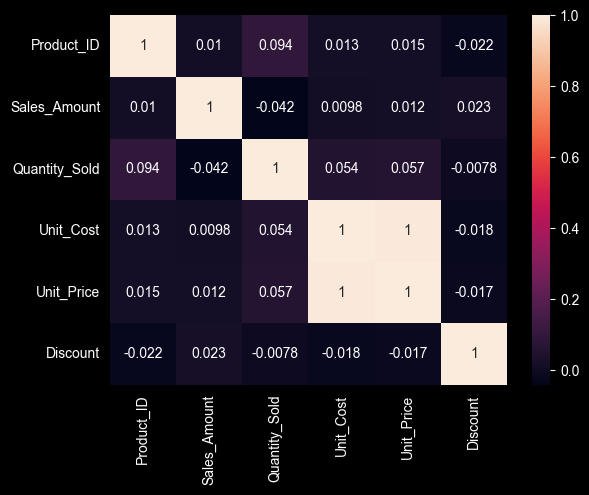

In [4]:
numerical_data = df.select_dtypes(include=['number'])
# numerical_data.corr()

sns.heatmap(numerical_data.corr(), annot=True)

# 2. Scatter

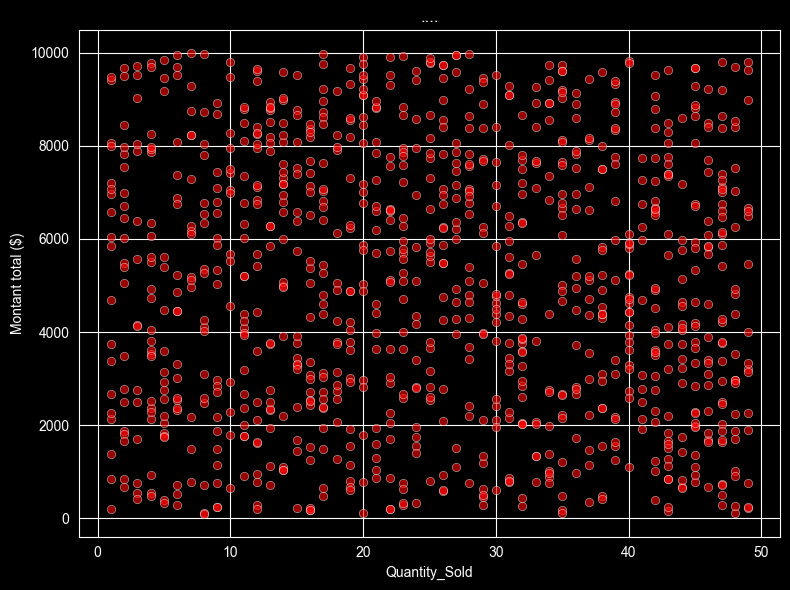

In [5]:
plt.figure(figsize=(8, 6))

sns.scatterplot( # Idéal pour analyser la relation entre deux variables numériques (corrélation, tendance)
    data=df,
    x='Quantity_Sold',
    y='Sales_Amount',
    color='red',
    alpha=0.6
)

plt.title("....")
plt.xlabel("Quantity_Sold")
plt.ylabel("Montant total ($)")


plt.tight_layout()
plt.show()

# 2. Countplot

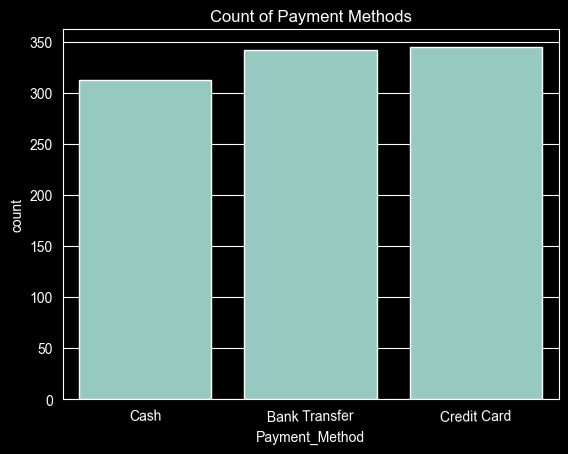

<Figure size 800x500 with 0 Axes>

In [6]:
sns.countplot(data=df, x="Payment_Method")

plt.title("Count of Payment Methods")
plt.xticks(rotation=1)
plt.figure(figsize=(8,5))
plt.show()

# 3. Pie chart

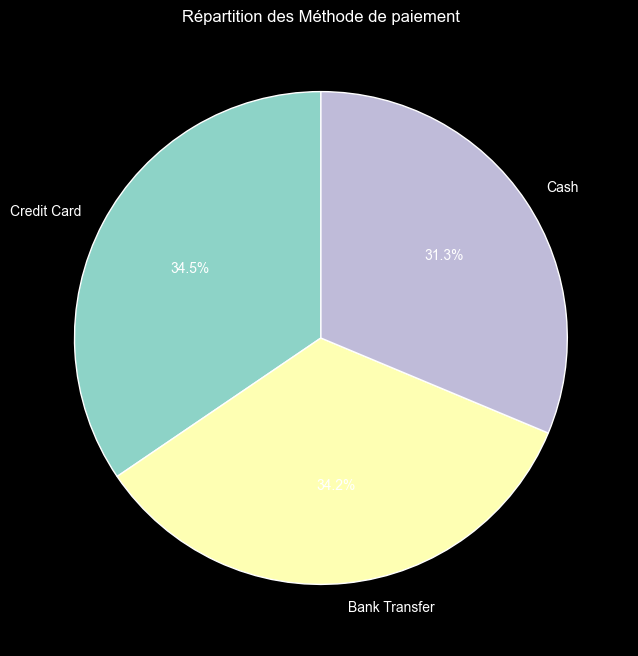

In [7]:
counts = df['Payment_Method'].value_counts() # Crée le variable en préparations des Donnees

plt.figure(figsize=(8, 8)) # Taille flexible
plt.pie(
    counts,
    labels=counts.index,
    autopct='%1.1f%%',
    startangle=90
)
plt.title("Répartition des Méthode de paiement")
plt.show()

# 4.  Bar Chart

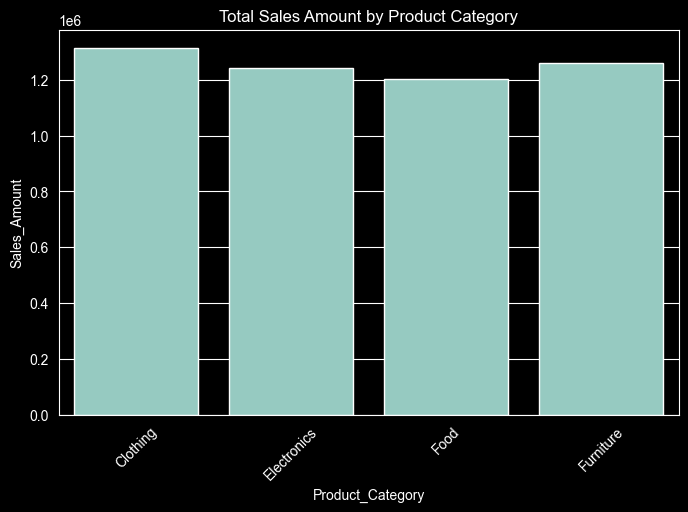

In [8]:

df_grouped = df.groupby("Product_Category")["Sales_Amount"].sum().reset_index() # Étape 1 : créer la variable (préparation des données)
plt.figure(figsize=(8,5))


sns.barplot(data=df_grouped, x="Product_Category", y="Sales_Amount") # Étape 2 : Visualiser avec Seaborn (simple)
plt.title("Total Sales Amount by Product Category")
plt.xticks(rotation=45)
plt.show()


# 5. Histogramme

<Axes: xlabel='Sales_Amount', ylabel='Count'>

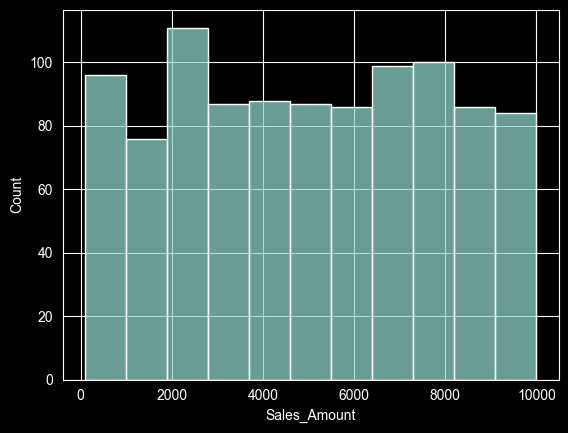

In [9]:
sns.histplot(data=df, x="Sales_Amount") # Idéal pour voir la distribution d’une variable numérique (répartition, valeurs fréquentes, extrêmes)


<Axes: xlabel='Sales_Amount', ylabel='Density'>

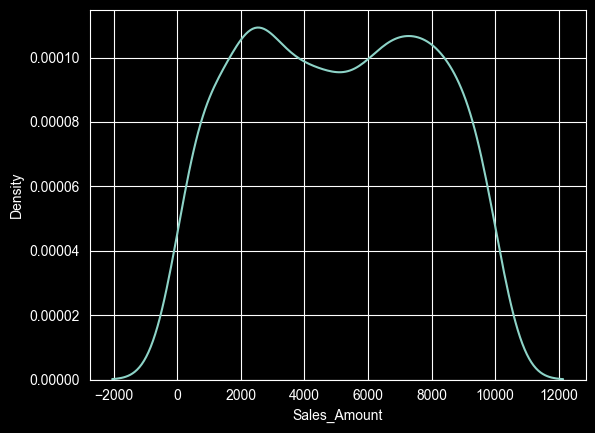

In [10]:
sns.kdeplot(data=df, x="Sales_Amount") # Idéal pour visualiser la forme de la distribution (plus lisse qu’un histogramme)


<Axes: xlabel='Unit_Price', ylabel='Quantity_Sold'>

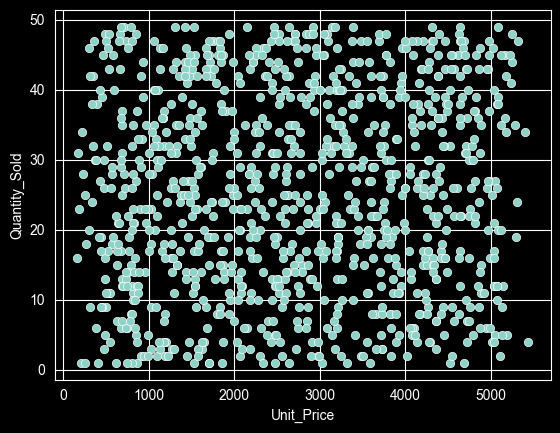

In [11]:
sns.scatterplot(data=df, x="Unit_Price", y="Quantity_Sold") # Idéal pour analyser la relation entre deux variables numériques (corrélation, tendance)


# 4. Boxplot

<Axes: xlabel='Region', ylabel='Sales_Amount'>

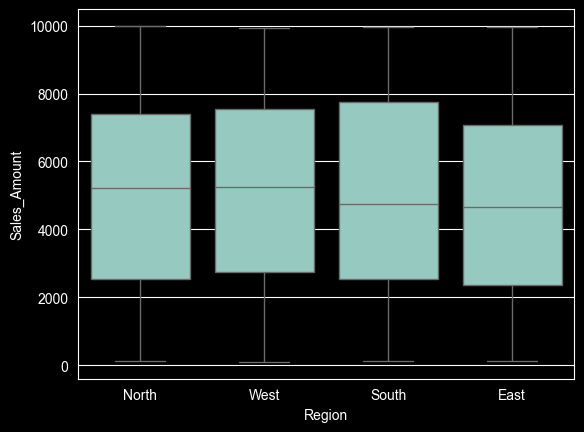

In [12]:
sns.boxplot(data=df, x="Region", y="Sales_Amount")
